🧩 Week 19 · Day 3 — Mixed Precision & Gradient Accumulation (CPU-Simulation)
Why this matters

Modern training balances speed vs precision. GPUs use mixed precision (FP16 + FP32) to go faster and save memory.
Even on CPU, you can simulate its effects and fully understand the math behind it.

🧠 Theory Essentials

FP32 (Full Precision): 32-bit floats — accurate, but slower and larger.

FP16 (Half Precision): 16-bit floats — faster, lighter, but less precise (rounding errors).

Mixed Precision: do most ops in FP16, keep critical ones (loss/gradients) in FP32.

Gradient Scaling: multiply losses to prevent underflow in FP16.

Gradient Accumulation: simulate large batches by accumulating several steps before updating weights — saves memory, even on CPU.

Trade-off: slight numerical noise ↔ big speed & memory gains.

Here’s what the (fixed) Week 19 · Day 3 script is doing, section by section:

### 1) Setup & dummy problem

* Creates a tiny **classification toy task**: inputs `x` (2000×512), labels `y` (10 classes).
* Defines a small **MLP**: `512 → 256 → 10` with ReLU.
* Uses cross-entropy loss and SGD/Adam optimizers.
* Seeds randomness so runs are comparable.

### 2) Mixed precision on **CPU** (bf16 autocast vs FP32)

Goal: **compare precision modes** to understand speed/behavior trade-offs.

* `run_precision("fp32")`: trains the model **entirely in FP32** for 50 steps.
* `run_precision("bf16")`: wraps the forward pass in

  ```python
  torch.autocast(device_type="cpu", dtype=torch.bfloat16)
  ```

  which executes eligible ops in **bfloat16** (a 16-bit format that works on CPU), while **keeping model weights & grads in FP32** for stability.
* Measures and prints **wall-clock time** for both modes:

  ```
  FP32: X.XXs | BF16 (autocast CPU): Y.YYs
  ```

  This *simulates* mixed precision benefits conceptually (true FP16 is GPU-only; CPU doesn’t support Half for Linear/MatMul).

Key ideas you’re meant to see:

* Mixed precision = do many ops in lower precision (bf16) but keep critical parts in FP32.
* On CPU you use **bf16 autocast**, not fp16.

### 3) Gradient Accumulation

Goal: **simulate larger batch sizes** without increasing memory.

* Chooses `batch_size = 128` and `accum_steps = 4`. Effective batch = `128 × 4 = 512`.
* Loop:

  * Compute loss on each micro-batch and **divide by `accum_steps`** so total gradient per “virtual batch” matches a single big batch.
  * Call `loss.backward()` **every micro-batch** to accumulate gradients in parameter `.grad`.
  * Every 4th micro-batch (`step % accum_steps == 0`), do `opt.step()` and `opt.zero_grad()`.
  * After the loop, if there’s a remainder (tail), it performs a final `opt.step()` so you don’t drop those gradients.

What you should take away:

* **Mixed precision** (here via CPU bf16 autocast) can speed up math and reduce memory while keeping stability with FP32 master weights.
* **Gradient accumulation** lets you keep a small physical batch size but behave like a larger one, which is crucial when memory is limited.


In [2]:
# Setup
import time, torch
import torch.nn as nn, torch.optim as optim
from contextlib import nullcontext

torch.manual_seed(0)
torch.set_num_threads(4)
device = torch.device("cpu")

# Dummy data & model
x = torch.randn(2000, 512, device=device)
y = torch.randint(0, 10, (2000,), device=device)

def make_model():
    torch.manual_seed(0)  # same init each run
    return nn.Sequential(
        nn.Linear(512, 256), nn.ReLU(),
        nn.Linear(256, 10)
    ).to(device)

loss_fn = nn.CrossEntropyLoss()

# --- Precision (FP32 vs "AMP on CPU" using bfloat16) ---
def run_precision(mode="fp32", epochs=50):
    m = make_model()
    opt = optim.SGD(m.parameters(), lr=0.01)

    # autocast only for bf16 on CPU; keep weights in FP32
    ctx = torch.autocast(device_type="cpu", dtype=torch.bfloat16) if mode=="bf16" else nullcontext()

    start = time.time()
    m.train()
    for _ in range(epochs):
        opt.zero_grad()
        with ctx:
            out = m(x)         # ops run in bf16 under autocast (where supported)
            loss = loss_fn(out, y)
        loss.backward()         # grads kept as FP32 master weights
        opt.step()
    return time.time() - start

t32  = run_precision("fp32")
tbf  = run_precision("bf16")
print(f"FP32: {t32:.2f}s | BF16 (autocast CPU): {tbf:.2f}s")

# --- Gradient Accumulation (robust pattern) ---
model = make_model()
opt = optim.Adam(model.parameters(), lr=1e-3)
batch_size, accum_steps = 128, 4

model.train()
opt.zero_grad()
step = 0
losses = []

for i in range(0, len(x), batch_size):
    xb = x[i:i+batch_size]
    yb = y[i:i+batch_size]

    out = model(xb)
    loss = loss_fn(out, yb) / accum_steps  # scale loss
    loss.backward()
    losses.append(loss.item())

    step += 1
    if step % accum_steps == 0:
        opt.step()
        opt.zero_grad()

# catch any leftover micro-batches
if step % accum_steps != 0:
    opt.step()
    opt.zero_grad()

print("Finished with gradient accumulation")


FP32: 1.13s | BF16 (autocast CPU): 2.70s
Finished with gradient accumulation


In this case FP32 is faster because my CPU doesn't support it.

1) Core (10–15 min)
Task: Run FP32 vs FP16 simulation 3 times and compare speed.

Can't really do this on CPU.

2) Practice (10–15 min)
Task: Change accum_steps to 2 and 8. Measure training time and final loss.

In [3]:

for accum_steps in [2, 8]:

    model = make_model()
    opt = optim.Adam(model.parameters(), lr=1e-3)
    batch_size = 128

    start = time.time()
    model.train()
    opt.zero_grad()
    step = 0
    losses = []

    for i in range(0, len(x), batch_size):
        xb = x[i:i+batch_size]
        yb = y[i:i+batch_size]

        out = model(xb)
        loss = loss_fn(out, yb) / accum_steps  # scale loss
        loss.backward()
        losses.append(loss.item())

        step += 1
        if step % accum_steps == 0:
            opt.step()
            opt.zero_grad()

    # catch any leftover micro-batches
    if step % accum_steps != 0:
        opt.step()
        opt.zero_grad()
    
    print(f"Final time using accum_steps {accum_steps}: {time.time() - start}")


Final time using accum_steps 2: 0.09381222724914551
Final time using accum_steps 8: 0.06117510795593262


3) Stretch (optional)
Task: Simulate mixed precision with NumPy matmuls: compare FP32 vs FP16 accuracy.

In [2]:
import numpy as np
a = np.random.randn(500,500).astype(np.float32)
b = np.random.randn(500,500).astype(np.float32)
fp32 = (a@b).mean()
print("fp32 done")
fp16 = (a.astype(np.float16)@b.astype(np.float16)).mean()
print(abs(fp32 - fp16))


fp32 done
5.716691e-06


🚀 Mini-Challenge (≤40 min)

Goal: Build a CPU benchmark comparing precision and accumulation.

Acceptance Criteria:

Table: columns = dtype, accum_steps, time (s), final loss.

Short plot of loss vs accum_steps.

Paragraph explaining: why gradient accumulation helps when batch size is limited.

  dtype  accum_steps  time_s  final_loss
0  fp32            1   0.184      2.3253
1  fp32            2   0.130      2.3214
2  fp32            4   0.111      2.3192
3  fp32            8   0.095      2.3189
4  bf16            1   0.300      2.3253
5  bf16            2   0.213      2.3213
6  bf16            4   0.183      2.3192
7  bf16            8   0.181      2.3190


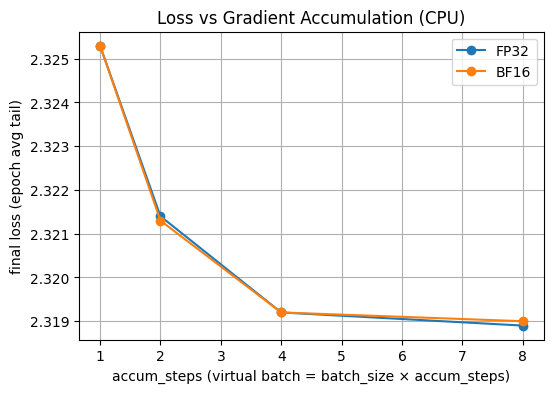

In [3]:
# Setup
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
np.random.seed(42)
plt.rcParams["figure.figsize"] = (6,4)
plt.rcParams["axes.grid"] = True

import time, torch
import torch.nn as nn, torch.optim as optim
from contextlib import nullcontext

torch.manual_seed(0)
torch.set_num_threads(4)
device = torch.device("cpu")

# ----- Toy dataset (classification) -----
N, D, H, C = 4000, 512, 256, 10
X = torch.randn(N, D, device=device)
y = torch.randint(0, C, (N,), device=device)

def make_model():
    torch.manual_seed(0)
    return nn.Sequential(
        nn.Linear(D, H), nn.ReLU(),
        nn.Linear(H, C)
    ).to(device)

loss_fn = nn.CrossEntropyLoss()

def train_one_pass(accum_steps=1, dtype_mode="fp32", batch_size=128):
    """
    Runs a single 'epoch' over X,y with gradient accumulation.
    dtype_mode: "fp32" or "bf16" (autocast on CPU).
    Returns: elapsed_time_seconds, final_loss (moving average over last 50 steps)
    """
    model = make_model()
    opt = optim.Adam(model.parameters(), lr=1e-3)

    # Autocast context for CPU bf16
    ctx = (torch.autocast(device_type="cpu", dtype=torch.bfloat16)
           if dtype_mode == "bf16" else nullcontext())

    model.train()
    opt.zero_grad()
    start = time.time()

    running_losses = []
    step = 0
    for i in range(0, N, batch_size):
        xb = X[i:i+batch_size]
        yb = y[i:i+batch_size]
        with ctx:
            out = model(xb)
            loss = loss_fn(out, yb) / accum_steps
        loss.backward()
        step += 1

        if step % accum_steps == 0:
            opt.step()
            opt.zero_grad()

        running_losses.append(loss.item() * accum_steps)  # unscaled loss for reporting

    # catch tail if any
    if step % accum_steps != 0:
        opt.step()
        opt.zero_grad()

    elapsed = time.time() - start
    # Smooth final loss (average over last 50 micro-batches or fewer)
    final_loss = float(np.mean(running_losses[-min(50, len(running_losses)):]))

    return elapsed, final_loss

# ----- Benchmark grid -----
accum_grid = [1, 2, 4, 8]
dtype_grid = ["fp32", "bf16"]  # bf16 via CPU autocast (for learning; may be slower)

rows = []
for dtype in dtype_grid:
    for accum in accum_grid:
        t, L = train_one_pass(accum_steps=accum, dtype_mode=dtype, batch_size=128)
        rows.append({"dtype": dtype, "accum_steps": accum, "time_s": round(t, 3), "final_loss": round(L, 4)})

df = pd.DataFrame(rows)
print(df)

# ----- Plot: loss vs accum_steps (one curve per dtype) -----
for dtype in dtype_grid:
    sub = df[df["dtype"] == dtype].sort_values("accum_steps")
    plt.plot(sub["accum_steps"], sub["final_loss"], marker="o", label=dtype.upper())
plt.xlabel("accum_steps (virtual batch = batch_size × accum_steps)")
plt.ylabel("final loss (epoch avg tail)")
plt.title("Loss vs Gradient Accumulation (CPU)")
plt.legend()
plt.show()


🧭 Notes / Key Takeaways

Mixed precision = smaller numbers → less memory & faster math.

Gradient scaling prevents underflow in FP16.

Gradient accumulation lets you train with “virtual” large batches.

CPU shows principles; GPUs show real speed gains (2–3×).

Always balance precision, speed, and stability.

💬 Reflection

When might you prefer gradient accumulation over increasing batch size?

Why does reducing precision save time but risk numerical instability?

1️⃣ When might you prefer gradient accumulation over increasing batch size?
You’d use gradient accumulation when your GPU or CPU memory can’t fit a large batch at once. Instead of loading one huge batch, you process several smaller micro-batches, accumulate their gradients, and update weights as if it were a single large batch. This gives the same training effect (smoother optimization, better generalization) without needing extra memory.

2️⃣ Why does reducing precision save time but risk numerical instability?
Lowering precision (FP32 → FP16/BF16) speeds up computation and reduces memory use because fewer bits are processed per operation. However, it also reduces numerical range and accuracy—small gradient values can underflow to zero or rounding errors can accumulate. This can make training unstable unless compensated by techniques like gradient scaling or keeping critical calculations (like loss) in FP32.